## Assignment 4

<br>

### Question 1
Investigate the model for predicting Diabetes disease progression by adding more explanatory variables to it in addition to `bmi` and `s5`.

a) Which variable would you add next? Why?

b) How does adding it affect the model's performance? Compute metrics and compare to having just `bmi` and `s5`.

d) Does it help if you add even more variables?

Include your own findings and explanations in code comments or inside triple quotes """...""".

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load diabetes dataset
diabetes = load_diabetes()

df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

df["target"] = diabetes.target

# Correlation with target
corr = df.corr()["target"].sort_values(
    key=abs,
    ascending=False
)

print(corr)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s3       -0.394789
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
Name: target, dtype: float64


In [2]:
# bmi and s5 already used
remaining = corr.drop(["target", "bmi", "s5"])

print(remaining)

bp     0.441482
s4     0.430453
s3    -0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: target, dtype: float64


In [3]:
new_feature = remaining.index[0]

print("Selected feature:", new_feature)

Selected feature: bp


In [4]:
X1 = df[["bmi", "s5"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X1,
    y,
    test_size=0.2,
    random_state=42
)

model1 = LinearRegression()
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

rmse1 = np.sqrt(
    mean_squared_error(y_test, pred1)
)

r21 = r2_score(y_test, pred1)

print("Baseline RMSE:", rmse1)
print("Baseline R2:", r21)

Baseline RMSE: 53.8687009455092
Baseline R2: 0.4522925957397932


In [5]:
X2 = df[["bmi", "s5", new_feature]]

X_train, X_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

model2 = LinearRegression()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

rmse2 = np.sqrt(
    mean_squared_error(y_test, pred2)
)

r22 = r2_score(y_test, pred2)

print("New RMSE:", rmse2)
print("New R2:", r22)

New RMSE: 53.768366269508
New R2: 0.45433099153843415


In [6]:
features = diabetes.feature_names

results = []

for i in range(2, len(features)+1):

    X = df[list(features[:i])]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    r2 = r2_score(y_test, pred)

    results.append([i, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["No_of_Features", "RMSE", "R2"]
)

print(results_df)

   No_of_Features       RMSE        R2
0               2  72.873289 -0.002334
1               3  63.692006  0.234323
2               4  60.981200  0.298112
3               5  61.013532  0.297368
4               6  60.806963  0.302118
5               7  55.092790  0.427118
6               8  55.514025  0.418324
7               9  54.011933  0.449376
8              10  53.853446  0.452603


### Question 2

Consider the dataset `50_Startups.csv` which contains data for companies' profit etc.

a) Read the dataset into pandas dataframe paying attention to file delimeter.

b) Identify the variables inside the dataset

c) Investigate the correlation between the variables

d) Choose appropriate variables to predict company profit. Justify your choice.

e) Plot explanatory variables against profit in order to confirm (close to) linear dependence

f) Form training and testing data (80/20 split)

g) Train linear regression model with training data

h) Compute RMSE and $R^2$ values for training and testing data separately

Include your own findings and explanations in code comments or inside triple quotes """...""".

In [7]:
import pandas as pd

# Read CSV file
df = pd.read_csv("50_Startups.csv")

print(df.head())
print(df.info())

   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB
None


In [8]:
print(df.columns)

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')


In [9]:
"""
Variables in the dataset:

Input Variables:
- R&D Spend
- Administration
- Marketing Spend
- State

Target Variable:
- Profit

State is a categorical variable.
The remaining variables are numerical.
"""

'\nVariables in the dataset:\n\nInput Variables:\n- R&D Spend\n- Administration\n- Marketing Spend\n- State\n\nTarget Variable:\n- Profit\n\nState is a categorical variable.\nThe remaining variables are numerical.\n'

In [11]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

                 R&D Spend  Administration  Marketing Spend    Profit
R&D Spend         1.000000        0.241955         0.724248  0.972900
Administration    0.241955        1.000000        -0.032154  0.200717
Marketing Spend   0.724248       -0.032154         1.000000  0.747766
Profit            0.972900        0.200717         0.747766  1.000000


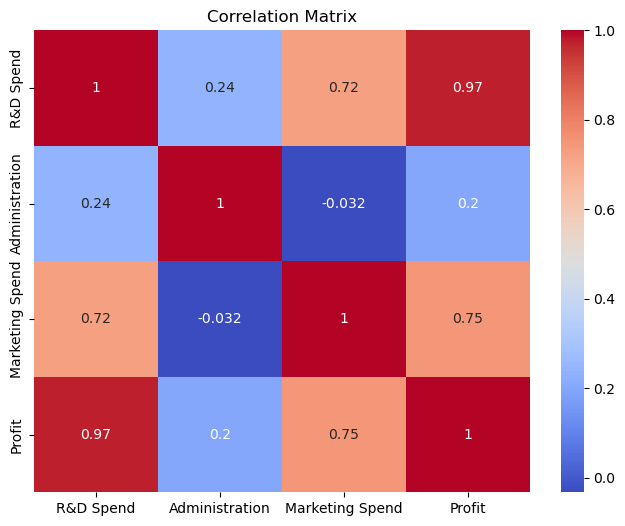

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [16]:
print(df.columns.tolist())

['R&D Spend', 'Administration', 'Marketing Spend', 'Profit', 'State_Florida', 'State_New York']


In [17]:
df.columns = df.columns.str.strip()

if "State" in df.columns:
    df = pd.get_dummies(df, columns=["State"], drop_first=True)

X = df.drop("Profit", axis=1)
y = df["Profit"]

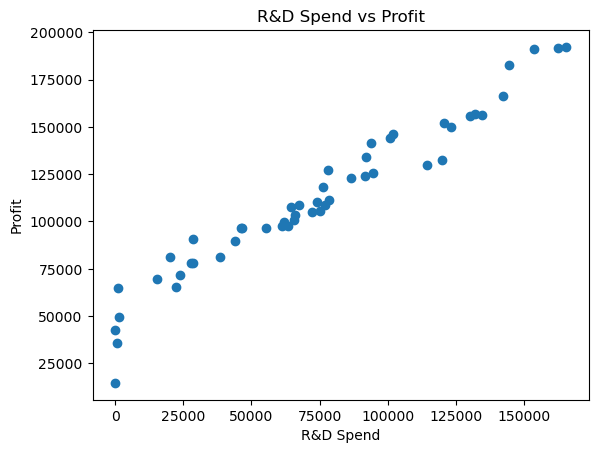

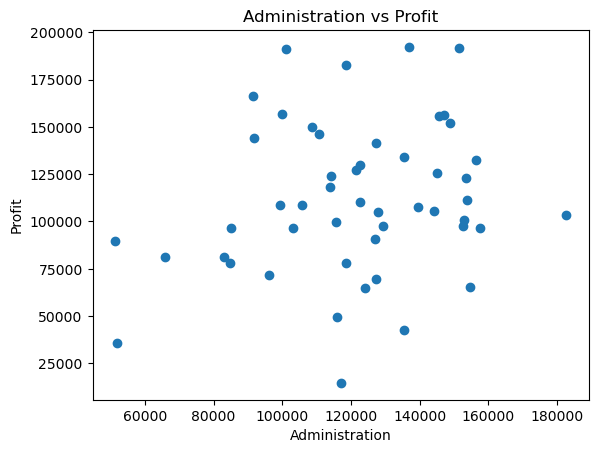

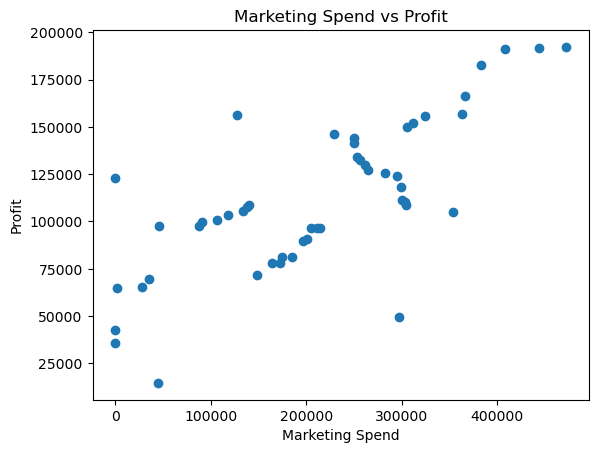

In [18]:
import matplotlib.pyplot as plt

plt.scatter(df["R&D Spend"], df["Profit"])
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("R&D Spend vs Profit")
plt.show()

plt.scatter(df["Administration"], df["Profit"])
plt.xlabel("Administration")
plt.ylabel("Profit")
plt.title("Administration vs Profit")
plt.show()

plt.scatter(df["Marketing Spend"], df["Profit"])
plt.xlabel("Marketing Spend")
plt.ylabel("Profit")
plt.title("Marketing Spend vs Profit")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40, 5)
(10, 5)


In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# RMSE
train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

# R²
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training RMSE: 8927.489013300055
Testing RMSE: 9055.957323458471
Training R²: 0.9537019995248526
Testing R²: 0.8987266414328636


### Question 3

Consider car performance data from the file `Auto.csv`.

a) Read the data into pandas dataframe

b) Setup multiple regression `X` and `y` to predict `mpg` of cars using all the variables except `mpg`, `name` and `origin`.

c) Split data into training and testing sets (80/20 split)

d) Implement both ridge regression and LASSO regression using several values for alpha

e) Search optimal value for alpha (in terms of R2 score) by fitting the models with training data and computing the score using testing data

f) Plot the R2 scores for both regressors as functions of alpha

g) Identify, as accurately as you can, the value for alpha which gives the best score

 
Include your own findings and explanations in code comments or inside triple quotes """...""".

In [22]:
import pandas as pd

df = pd.read_csv("Auto.csv")

print(df.head())
print(df.info())

    mpg  cylinders  displacement horsepower  weight  acceleration  year  \
0  18.0          8         307.0        130    3504          12.0    70   
1  15.0          8         350.0        165    3693          11.5    70   
2  18.0          8         318.0        150    3436          11.0    70   
3  16.0          8         304.0        150    3433          12.0    70   
4  17.0          8         302.0        140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    floa

In [24]:
# Drop unwanted columns
X = df.drop(columns=["mpg", "name", "origin"])

y = df["mpg"]

print(X.head())

   cylinders  displacement  horsepower  weight  acceleration  year
0          8         307.0         130    3504          12.0    70
1          8         350.0         165    3693          11.5    70
2          8         318.0         150    3436          11.0    70
3          8         304.0         150    3433          12.0    70
4          8         302.0         140    3449          10.5    70


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

import numpy as np

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_scores = []
lasso_scores = []

for alpha in alphas:
    
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_pred = ridge.predict(X_test_scaled)
    ridge_scores.append(r2_score(y_test, ridge_pred))
    
    # LASSO
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_pred = lasso.predict(X_test_scaled)
    lasso_scores.append(r2_score(y_test, lasso_pred))

print("Ridge scores:", ridge_scores)
print("Lasso scores:", lasso_scores)

Ridge scores: [0.7942342139868102, 0.7942279741593583, 0.7941657908964388, 0.7935649350725311, 0.7891628670216875, 0.7770376555372411]
Lasso scores: [0.7939841711290274, 0.7938509861823811, 0.7968669007094491, 0.80194038317943, -0.011357808240890499, -0.011357808240890499]


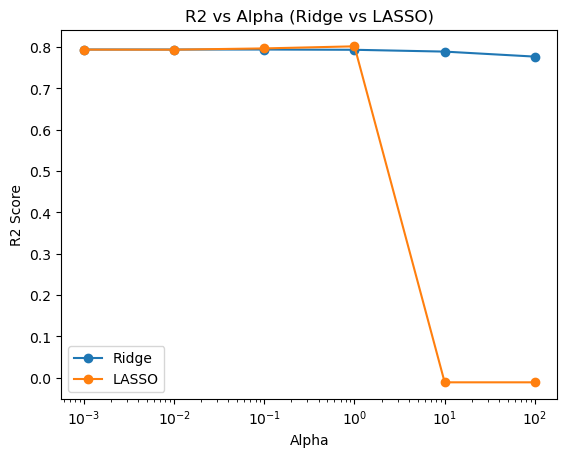

In [29]:
import matplotlib.pyplot as plt

plt.plot(alphas, ridge_scores, marker="o", label="Ridge")
plt.plot(alphas, lasso_scores, marker="o", label="LASSO")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.title("R2 vs Alpha (Ridge vs LASSO)")
plt.legend()
plt.show()

In [31]:
best_ridge_idx = np.argmax(ridge_scores)
best_lasso_idx = np.argmax(lasso_scores)

print("Best Ridge Alpha:", alphas[best_ridge_idx])
print("Best Ridge R2:", ridge_scores[best_ridge_idx])

print("Best LASSO Alpha:", alphas[best_lasso_idx])
print("Best LASSO R2:", lasso_scores[best_lasso_idx])

Best Ridge Alpha: 0.001
Best Ridge R2: 0.7942342139868102
Best LASSO Alpha: 1
Best LASSO R2: 0.80194038317943
